# SMS Spam Classification — Exploratory Data Analysis

This notebook performs a concise EDA on the `SMSSpamCollection` dataset and trains a TF-IDF + Logistic Regression baseline model.

**Dataset:** SMSSpamCollection — a corpus of SMS messages labeled as `ham` (legitimate) or `spam`.

**Reference model:** [Goodmotion/spam-mail-classifier](https://huggingface.co/Goodmotion/spam-mail-classifier) — a multilingual two-class classifier fine-tuned on e-mail subjects. Note: there is a domain mismatch between that model (e-mail) and this dataset (SMS), so results may differ.

**Team:** Fabian A. Salazar Figueroa · Luis E. Ordoñez Erazo · Raúl A. Echeverry López

## 1. Imports

All required libraries are imported here at the top so the notebook is self-contained and dependencies are clear at a glance.

In [1]:
# Standard library
import re
from collections import Counter
from pathlib import Path

# Data manipulation
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

sns.set(style="whitegrid")
print("All imports OK")

All imports OK


## 2. Load Dataset

The `SMSSpamCollection` file is a tab-separated text file with two columns:
- `label`: either `ham` (legitimate) or `spam`
- `text`: the raw SMS message

The code below searches for the file starting from the notebook directory and walking up to the repository root, so it works regardless of where Jupyter is launched from.

In [2]:
# Locate the dataset file by searching up from the current directory
search_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd().parent.parent.parent,
]
data_path = None
for root in search_roots:
    for candidate in (root / "SMSSpamCollection", root / "data" / "SMSSpamCollection"):
        if candidate.exists():
            data_path = candidate
            break
    if data_path is not None:
        break

if data_path is None:
    raise FileNotFoundError(
        "SMSSpamCollection not found. "
        "Place the file in the repository root or in data/ and re-run."
    )

# Read the tab-separated file (label \t text, no header)
df = pd.read_csv(data_path, sep="\t", header=None, names=["label", "text"])
print(f"Dataset loaded from: {data_path}")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded from: c:\Users\Lenovo\github\Taller\SMSSpamCollection
Shape: (5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3. Class Distribution

We first check how many messages belong to each class. An imbalanced dataset (many more `ham` than `spam`) is expected and is important to consider when evaluating model performance — accuracy alone can be misleading.

label
ham     4825
spam     747
Name: count, dtype: int64


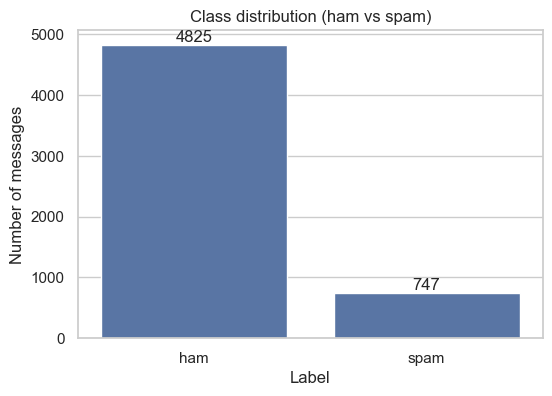

In [3]:
# Count messages per class and plot
counts = df["label"].value_counts()
print(counts)

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=counts.index, y=counts.values, color="#4c72b0")
ax.set_xlabel("Label")
ax.set_ylabel("Number of messages")
ax.set_title("Class distribution (ham vs spam)")
for i, v in enumerate(counts.values):
    ax.text(i, v + max(counts.values) * 0.01, str(v), ha="center")
plt.show()

## 4. Message Length by Class

Spam messages tend to be longer than legitimate ones — they often contain URLs, phone numbers, and promotional text. Computing the average character length per class gives us a quick sanity check and a potential feature for future models.

  label  count        mean  median
0   ham   4825   71.482487    52.0
1  spam    747  138.670683   149.0


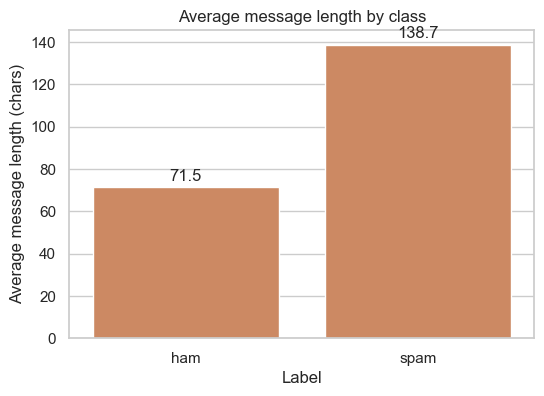

In [4]:
# Add a character-length column and compute per-class statistics
df["length"] = df["text"].str.len()
length_stats = df.groupby("label")["length"].agg(["count", "mean", "median"]).reset_index()
print(length_stats)

# Bar chart: average message length per class
plt.figure(figsize=(6, 4))
ax = sns.barplot(x="label", y="mean", data=length_stats, color="#dd8452")
ax.set_xlabel("Label")
ax.set_ylabel("Average message length (chars)")
ax.set_title("Average message length by class")
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), ".1f"),
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
    )
plt.show()

## 5. Most Frequent Words per Class

Simple word-frequency analysis (without stop-word removal) reveals vocabulary differences between spam and ham. For example, words like *free*, *call*, and *txt* are more common in spam, while ham tends to use more conversational language.

Tokens shorter than 3 characters are excluded to reduce noise from single letters and common abbreviations.

Top 10 words in SPAM:
[('call', 355), ('you', 297), ('your', 264), ('free', 224), ('the', 206), ('for', 204), ('now', 199), ('txt', 163), ('have', 135), ('from', 131)]

Top 10 words in HAM:
[('you', 1948), ('the', 1133), ('and', 858), ('that', 560), ('for', 507), ('have', 443), ('can', 441), ('but', 441), ('not', 421), ('your', 417)]


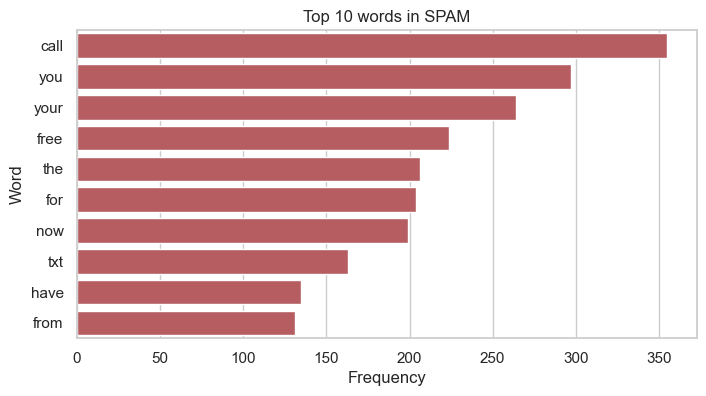

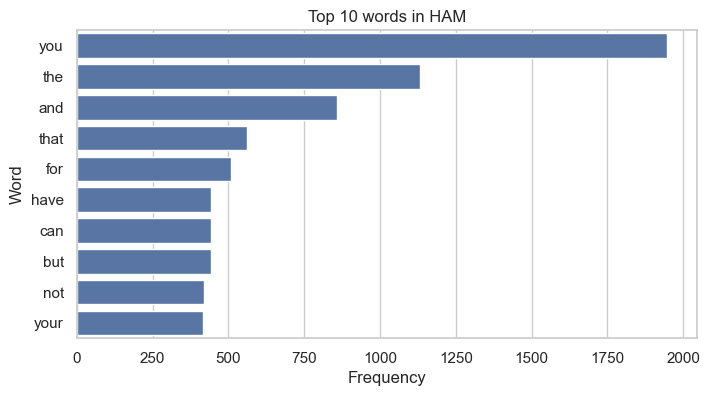

In [5]:
def tokenize(text):
    """Lowercase word tokenizer using only alphabetic characters."""
    return re.findall(r"\b[a-zA-Z]+\b", str(text).lower())


def top_n_words(df_sub, n=10):
    """Return the n most common words (length > 2) in the given subset."""
    cnt = Counter()
    for t in df_sub["text"]:
        tokens = [w for w in tokenize(t) if len(w) > 2]
        cnt.update(tokens)
    return cnt.most_common(n)


top_spam = top_n_words(df[df["label"] == "spam"], n=10)
top_ham = top_n_words(df[df["label"] == "ham"], n=10)

print("Top 10 words in SPAM:")
print(top_spam)
print("\nTop 10 words in HAM:")
print(top_ham)


def plot_top(top_list, title, color="#dd8452"):
    """Horizontal bar chart for word frequencies."""
    if not top_list:
        print("No words to plot for", title)
        return
    words, freqs = zip(*top_list)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=list(freqs), y=list(words), color=color)
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.show()


plot_top(top_spam, "Top 10 words in SPAM", color="#c44e52")
plot_top(top_ham, "Top 10 words in HAM", color="#4c72b0")

## 6. Baseline Model — TF-IDF + Logistic Regression

Before using a pre-trained transformer, we establish a classical baseline:

1. **TF-IDF vectorizer** converts raw SMS text into numeric features (unigrams + bigrams, minimum document frequency of 2, English stop words removed).
2. **Logistic Regression** is a fast and interpretable linear classifier well suited to text classification.

The dataset is split 80/20 (train/test) with stratification so both splits preserve the original class ratio.

In [6]:
# Split data (stratified to preserve class ratio)
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build and train the pipeline
baseline_model = Pipeline(
    [
        ("tfidf", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2)),
        ("clf", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)

baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)

# Summary metrics
metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision_spam": precision_score(y_test, y_pred, pos_label="spam"),
    "recall_spam": recall_score(y_test, y_pred, pos_label="spam"),
    "f1_spam": f1_score(y_test, y_pred, pos_label="spam"),
}
metrics

{'accuracy': 0.9704035874439462,
 'precision_spam': 1.0,
 'recall_spam': 0.7785234899328859,
 'f1_spam': 0.8754716981132076}

## 7. Evaluation Report

The full classification report and confusion matrix provide a more detailed view of model performance:

- **Precision** (spam): fraction of predicted spam that is actually spam — high precision means few false alarms.
- **Recall** (spam): fraction of actual spam correctly detected — high recall means few missed spam messages.
- **F1** (spam): harmonic mean of precision and recall.

The fitted pipeline is saved to `models/baseline_model.pkl` so it can be loaded directly by the Streamlit app without retraining.

In [7]:
# Full classification report
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

# Save the trained pipeline
project_root = data_path.parent
models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / "baseline_model.pkl"
joblib.dump(baseline_model, model_path)
print(f"\nModel saved to: {model_path}")

              precision    recall  f1-score   support

         ham     0.9670    1.0000    0.9832       966
        spam     1.0000    0.7785    0.8755       149

    accuracy                         0.9704      1115
   macro avg     0.9835    0.8893    0.9293      1115
weighted avg     0.9714    0.9704    0.9688      1115

Confusion matrix:
[[966   0]
 [ 33 116]]

Model saved to: c:\Users\Lenovo\github\Taller\models\baseline_model.pkl
